In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

**Loading cleaned dataset of movies**

In [2]:
df = pd.read_csv("/content/cleaned_movies.csv")

In [3]:
df.describe()

,Unnamed: 0,year,rating,duration,votes,gross_income
count,19808.000000,19808.000000,19808.000000,19808.000000,1.980800e+04,1.980800e+04
mean,9903.500000,1995.546597,6.041973,101.777968,3.694303e+04,1.682198e+07
std,5718.221402,22.801725,1.206831,43.178721,1.129755e+05,4.642034e+07
min,0.000000,1894.000000,1.100000,1.000000,5.000000e+00,0.000000e+00
25%,4951.750000,1983.000000,5.300000,90.000000,1.058000e+03,1.196010e+05
50%,9903.500000,2003.000000,6.200000,98.000000,4.233000e+03,1.158192e+06
75%,14855.250000,2014.000000,6.900000,111.000000,2.045350e+04,1.243278e+07
max,19807.000000,2022.000000,9.700000,5220.000000,2.574832e+06,9.366622e+08


**Plot the distribution of movie ratings (Histogram)**

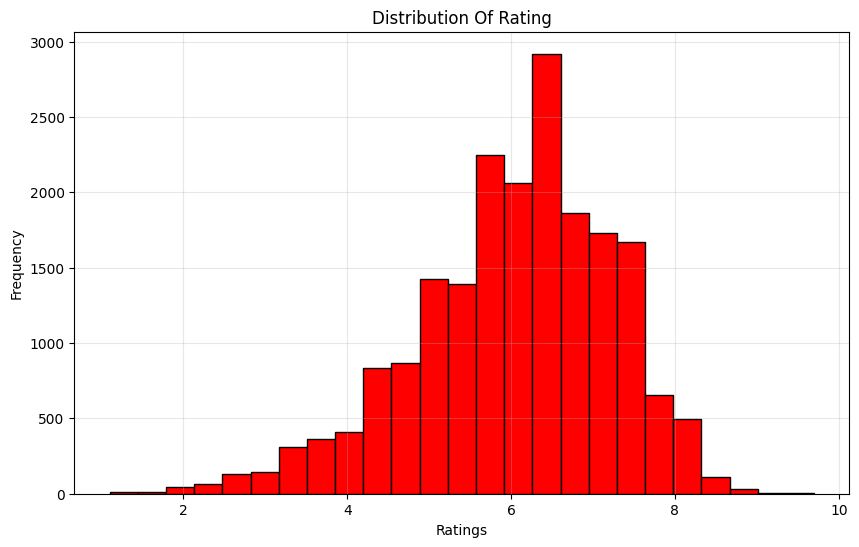

In [4]:
plt.figure(figsize=(10,6))
plt.hist(df["rating"], color="red", edgecolor="black", bins=25)
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.title("Distribution Of Rating")
plt.grid(alpha=0.3) # alpha -> opacity -> transparancy
plt.show()

In [5]:
df["rating"].mean()

np.float64(6.041972940226171)

In [6]:
df["rating"].mode()

,rating
0,6.4


In [7]:
df["rating"].median()

6.2

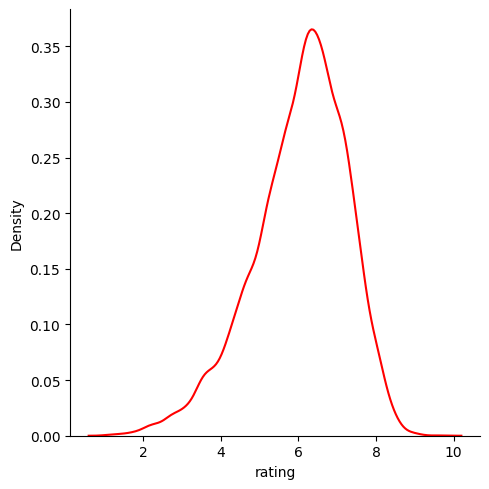

In [8]:
sns.displot(df["rating"], color="red", kind="kde")
# Rating tends to Normal distribution
# also by value above mean, median and mode are somhow similar

**Which are the top 10 most frequent actors ? (Bar Chart)**

In [9]:
a=df["stars_name"].str.split(",").explode()
top_ten = a.value_counts().head(10)
top_ten

,count
stars_name,
Nicolas Cage,76
Samuel L. Jackson,72
Bruce Willis,71
John Wayne,71
Robert De Niro,62
Michael Caine,62
Jackie Chan,59
Donald Sutherland,58
Willem Dafoe,56


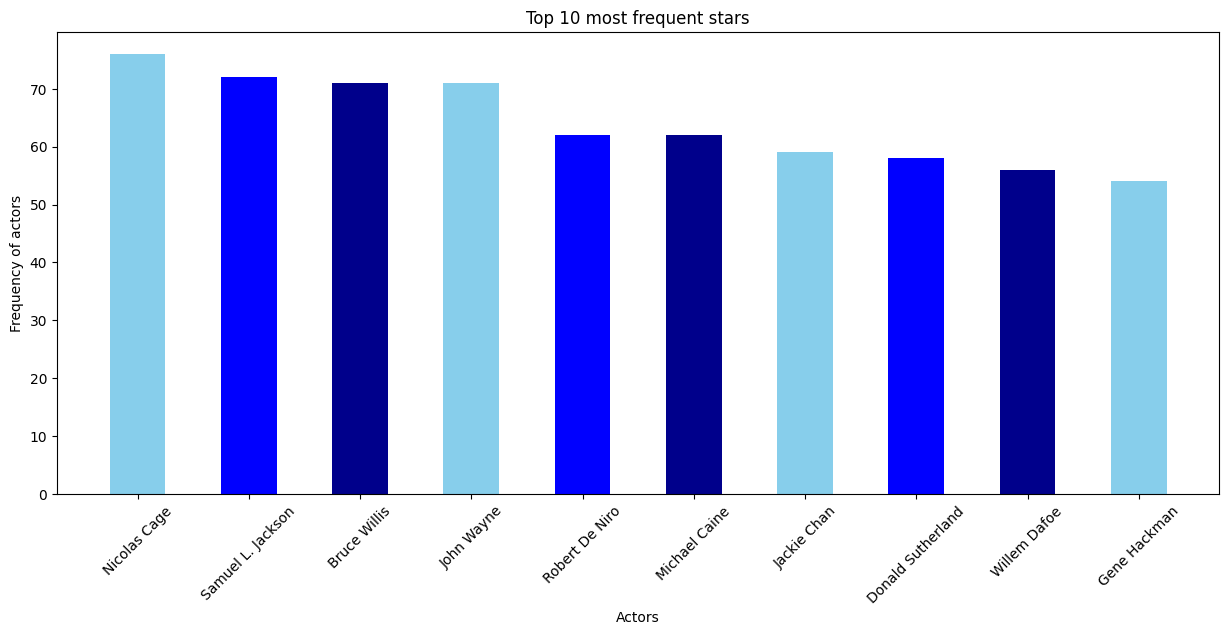

In [10]:
plt.figure(figsize=(15,6))
plt.bar(top_ten.index,top_ten.values, width=0.5, color=["skyblue","blue","darkblue"])
plt.xticks(rotation=45)
plt.xlabel("Actors")
plt.ylabel("Frequency of actors")
plt.title("Top 10 most frequent stars")
plt.show()

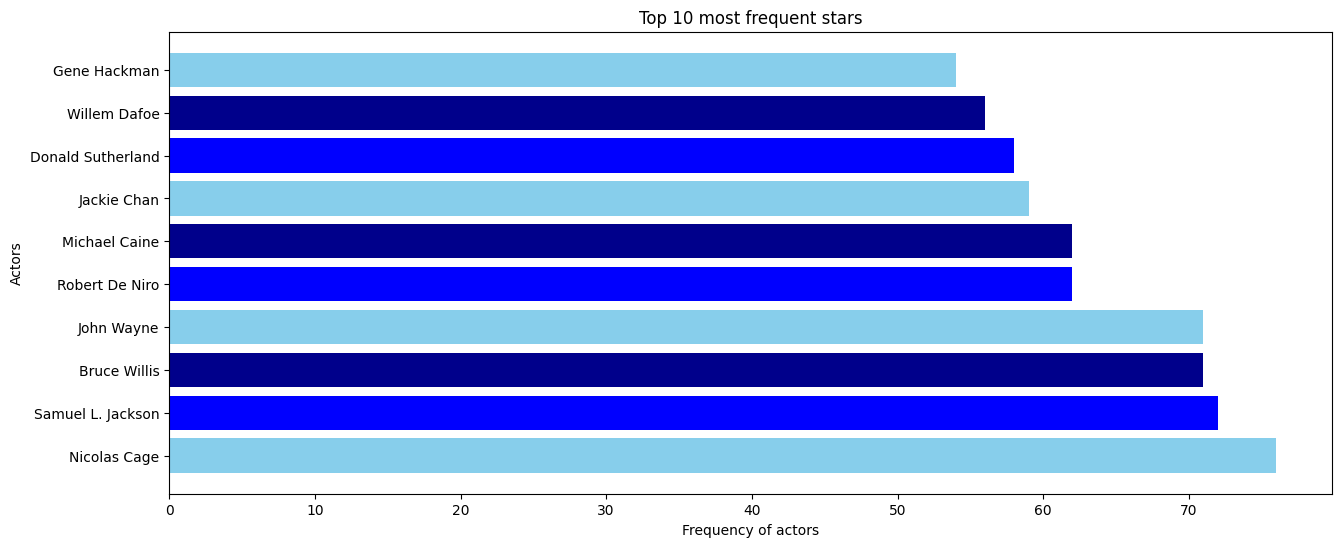

In [11]:
# Horizontal Bar chart

plt.figure(figsize=(15,6))
plt.barh(top_ten.index,top_ten.values, color=["skyblue","blue","darkblue"])
plt.ylabel("Actors")
plt.xlabel("Frequency of actors")
plt.title("Top 10 most frequent stars")
plt.show()

**Plot the relationship between year and rating (Scatterplot)**

Text(0.5, 1.0, 'Relationship between Year and Rating')

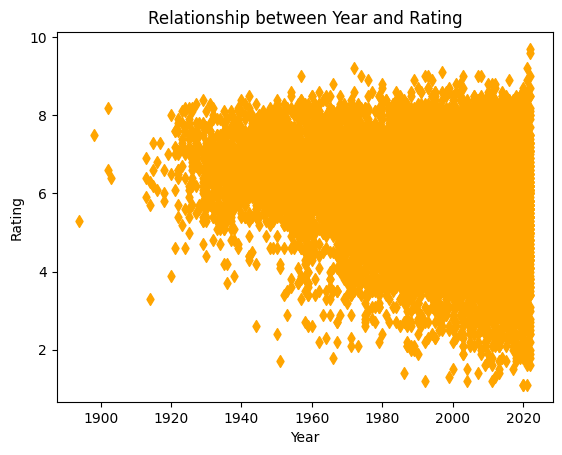

In [12]:
plt.scatter(df["year"], df["rating"], color="orange",marker='d')
plt.xlabel("Year")
plt.ylabel("Rating")
plt.title("Relationship between Year and Rating")

# As year is increasing rating is also increasing

**Plot distribution of Gross Income and Votes (Box Plot)**

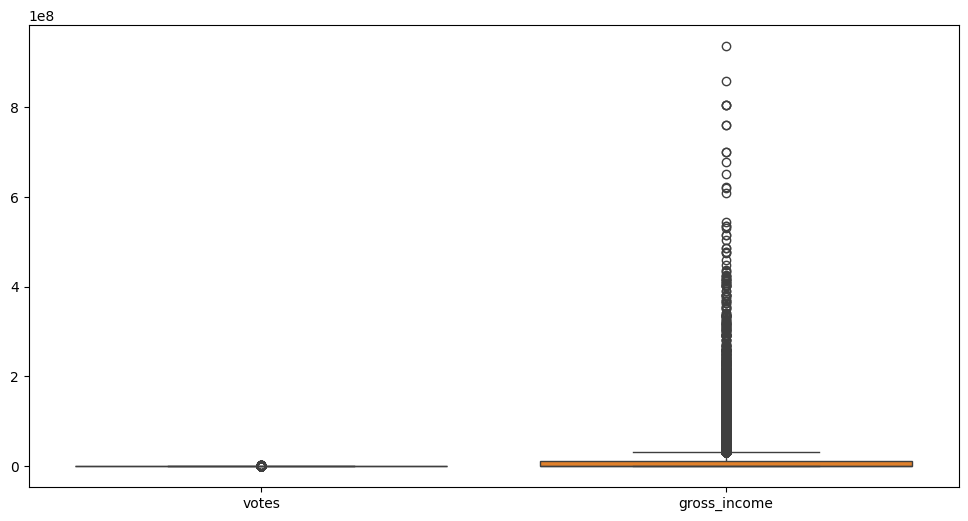

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=[df["votes"],df["gross_income"]])
plt.show()



**Plot the correlation between Rating, Votes and Gross Income (Heat Map)**

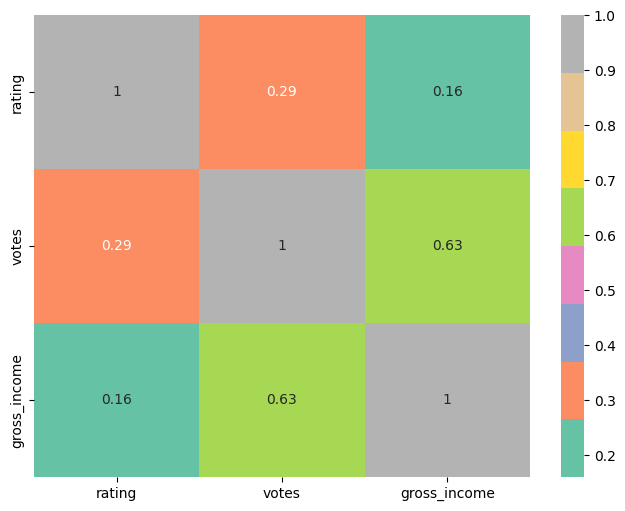

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["rating","votes","gross_income"]].corr(), annot=True, cmap="Set2")
plt.show()

In [15]:
df[["rating","votes","gross_income"]].corr()

,rating,votes,gross_income
rating,1.000000,0.286922,0.159105
votes,0.286922,1.000000,0.632683
gross_income,0.159105,0.632683,1.000000


**Plot correlation between all numeric columns (Heat Map)**

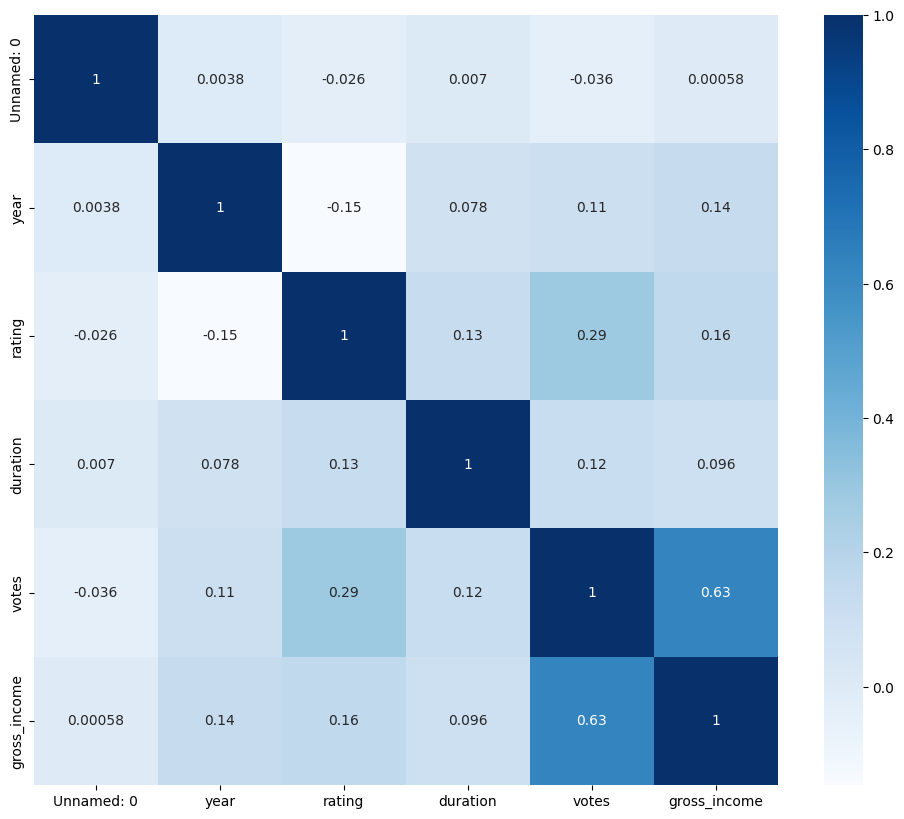

In [16]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.show()

In [17]:
df.corr(numeric_only=True)

,Unnamed: 0,year,rating,duration,votes,gross_income
Unnamed: 0,1.000000,0.003848,-0.025981,0.006986,-0.036195,0.000584
year,0.003848,1.000000,-0.146652,0.078304,0.106825,0.138669
rating,-0.025981,-0.146652,1.000000,0.130112,0.286922,0.159105
duration,0.006986,0.078304,0.130112,1.000000,0.123045,0.095720
votes,-0.036195,0.106825,0.286922,0.123045,1.000000,0.632683
gross_income,0.000584,0.138669,0.159105,0.095720,0.632683,1.000000


**Plot the average movie rating over the years (Line Chart)**

In [18]:
avg_rating = df.groupby("year")["rating"].mean().sort_index()
avg_rating.head()

,rating
year,
1894,5.3
1898,7.5
1902,7.4
1903,6.4
1913,6.4


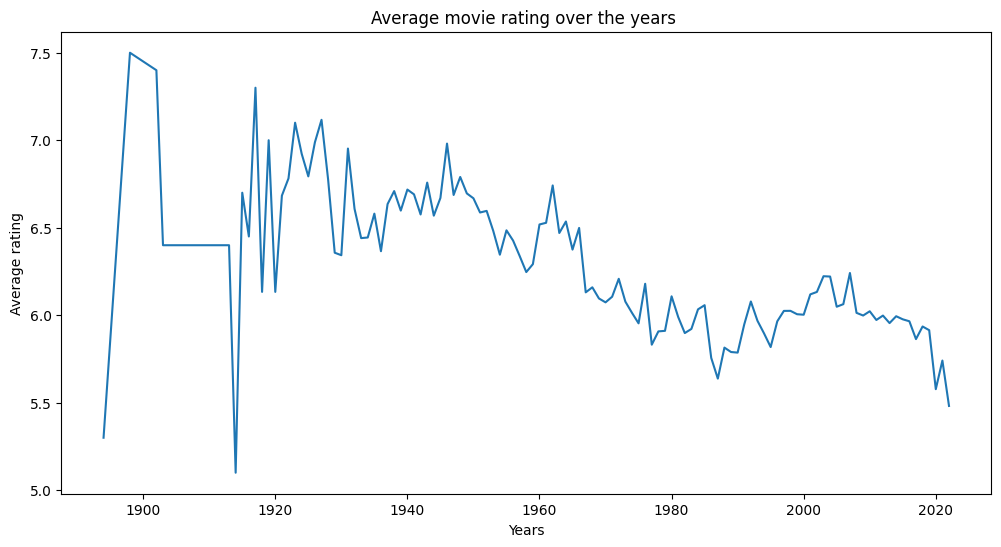

In [19]:
plt.figure(figsize=(12,6))
plt.plot(avg_rating.index, avg_rating.values)
plt.xlabel("Years")
plt.ylabel("Average rating")
plt.title("Average movie rating over the years ")
plt.show()

**Plot the number of movies released per year (Line Chart)**

In [20]:
movies_per_year = df["year"].value_counts().sort_index()
movies_per_year.head(5)

,count
year,
1894,1
1898,1
1902,2
1903,1
1913,3


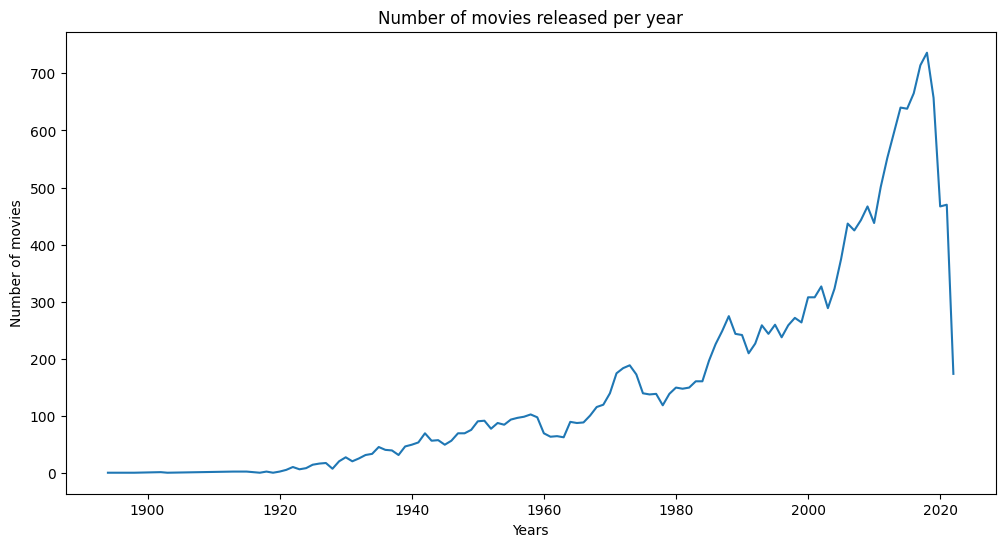

In [21]:
plt.figure(figsize=(12,6))
plt.plot(movies_per_year.index, movies_per_year.values)
plt.xlabel("Years")
plt.ylabel("Number of movies")
plt.title("Number of movies released per year")
plt.show()

**Plot the count of movies for the top rated actors (Count Plot using Seaborn)**

In [66]:
# First splitting actors by commas and making a row for each indivisual actor
# Second we found out max rating of all actors and sorting them in descending order according to their max rating
# Getting top 15 actor names from max rating list

f = df.assign(stars_name = df["stars_name"].str.split(",")).explode("stars_name")
top_actors = f.groupby("stars_name")["rating"].max().sort_values(ascending=False)
names = top_actors.head(15).index
print("Top rated actors name : ",names)

Top rated actors name :  Index(['Eugene Mirman', 'Dan Mintz', 'Larry Murphy', 'H. Jon Benjamin',
       'Glenn Ennis', 'Philip Granger', 'Vinnie Jones', 'Lina Lecompte',
       'Karl J. Arana', 'Diane Keaton', 'Eduardo Castrillo', 'Maurizio Bandi',
       'Noel Castrillo', 'James Caan', 'Marlon Brando'],
      dtype='object', name='stars_name')


In [67]:
# Getting those rows from the dataframe which contains these top 15 actors
# Getting no of movies for each of these actors

g = f[(f["stars_name"].isin(names))]
g["stars_name"].value_counts()

,count
stars_name,
James Caan,37
Marlon Brando,27
Vinnie Jones,20
Diane Keaton,9
H. Jon Benjamin,2
Dan Mintz,2
Eugene Mirman,1
Larry Murphy,1
Karl J. Arana,1


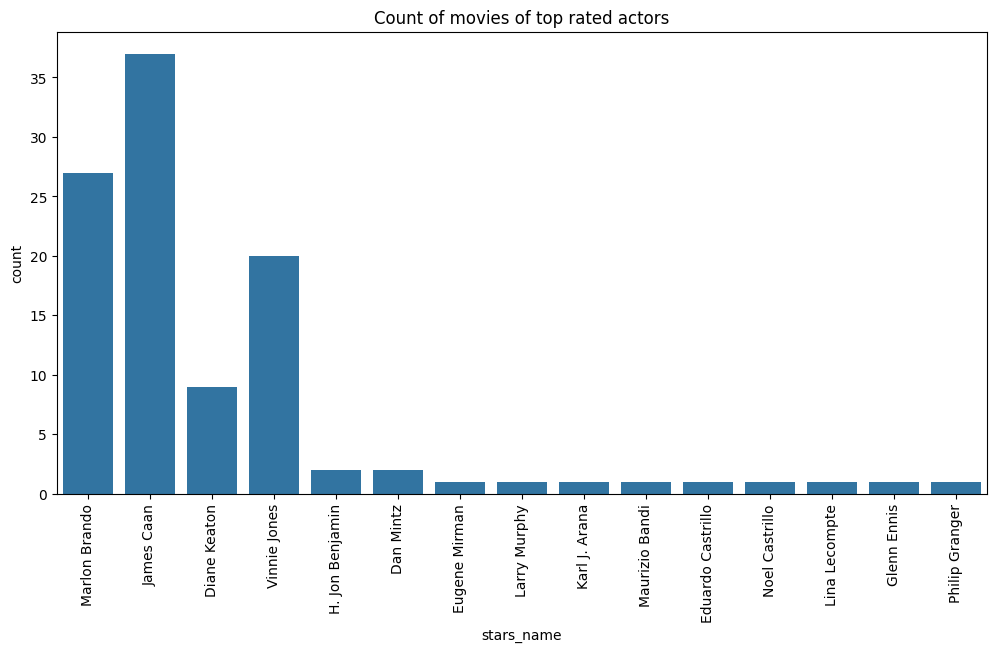

In [70]:
plt.figure(figsize=(12,6))
plt.xticks(rotation=90)
plt.title("Count of movies of top rated actors")
sns.countplot(x=g["stars_name"], data=g)
plt.show()